In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/customer_churn.csv")
print(df.shape)
df.head()

(10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [5]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [6]:
missing = df.isnull().sum()
missing[missing > 0]

complaint_type    2045
dtype: int64

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


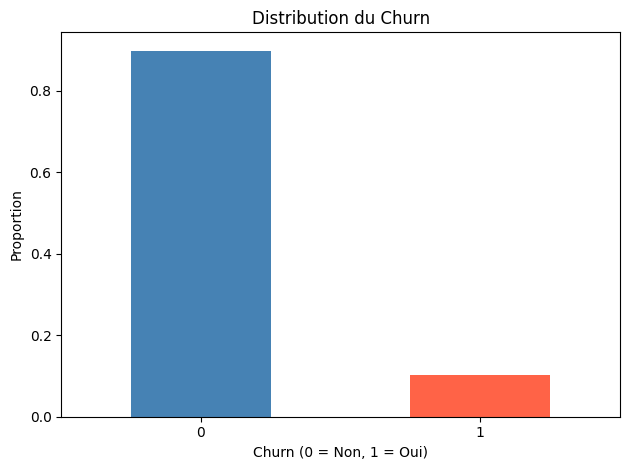

In [7]:
churn_counts = df['churn'].value_counts(normalize=True)
print(churn_counts)

churn_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Distribution du Churn")
plt.xlabel("Churn (0 = Non, 1 = Oui)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

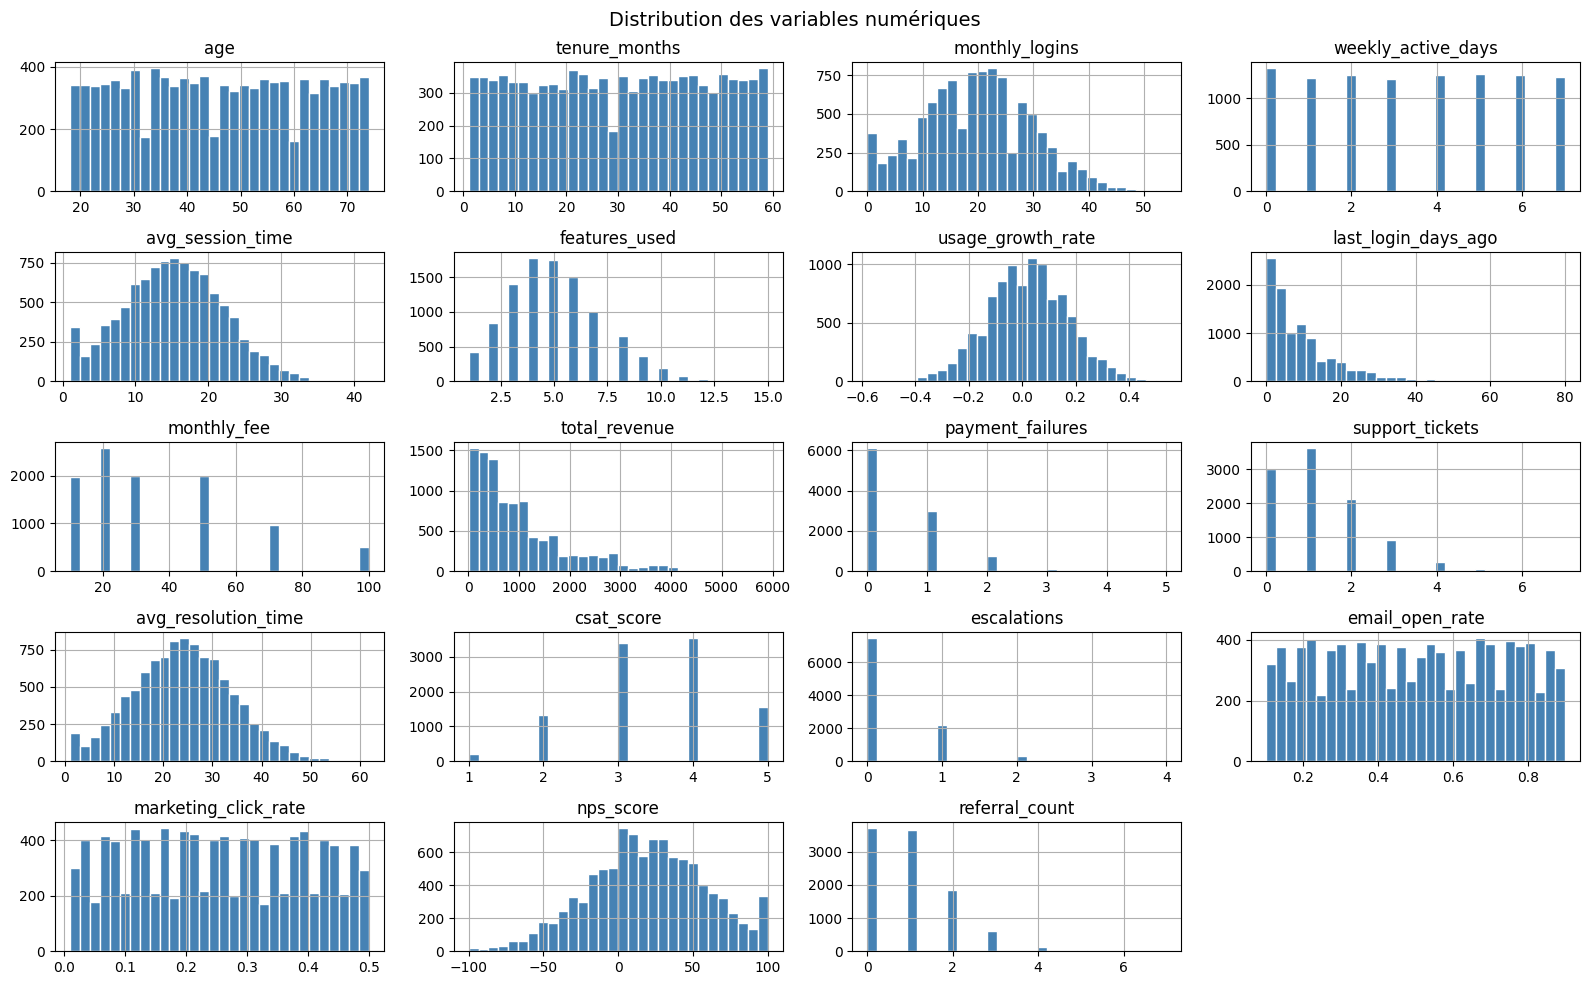

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [col for col in num_cols if col != 'churn']

df[num_cols].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Colonnes catégorielles :", cat_cols)

for col in cat_cols:
    print(f"\n{col} :")
    print(df[col].value_counts())

Colonnes catégorielles : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

customer_id :
customer_id
CUST_09984    1
CUST_09983    1
CUST_09982    1
CUST_09981    1
CUST_09980    1
             ..
CUST_00005    1
CUST_00004    1
CUST_00003    1
CUST_00002    1
CUST_00001    1
Name: count, Length: 10000, dtype: int64

gender :
gender
Male      5013
Female    4987
Name: count, dtype: int64

country :
country
Bangladesh    1494
Canada        1488
USA           1442
India         1427
Australia     1400
UK            1382
Germany       1367
Name: count, dtype: int64

city :
city
London      1518
Sydney      1471
Dhaka       1459
Delhi       1402
Berlin      1386
New York    1385
Toronto     1379
Name: count, dtype: int64

customer_segment :
customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64



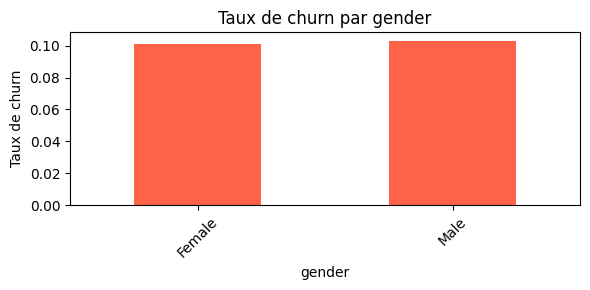

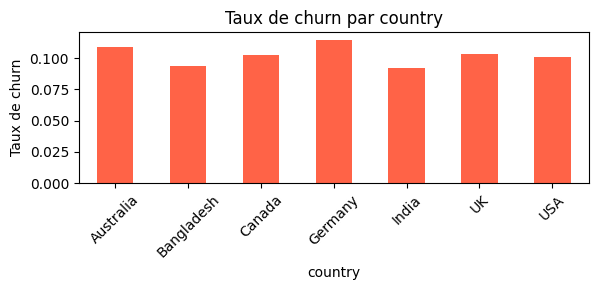

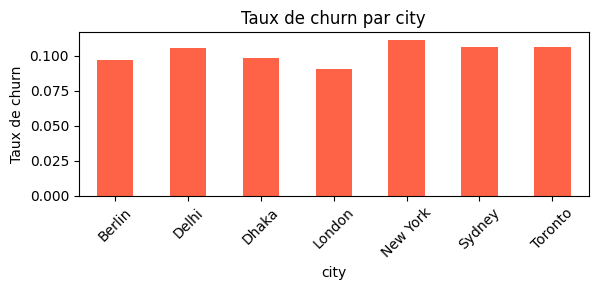

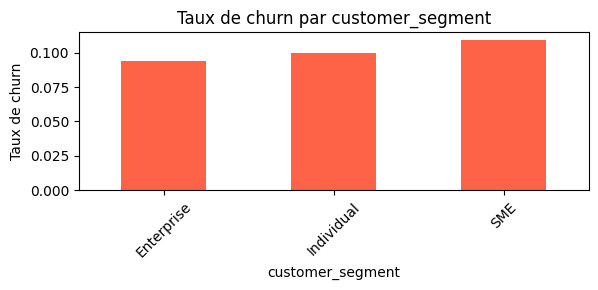

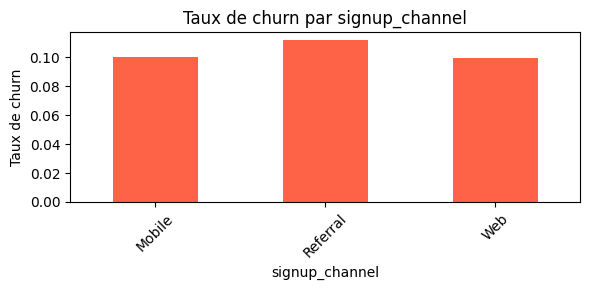

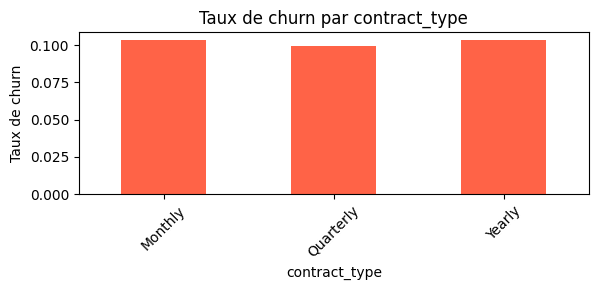

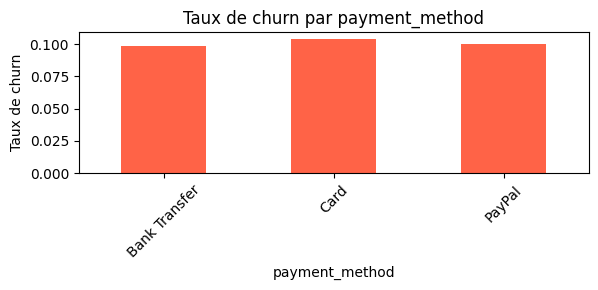

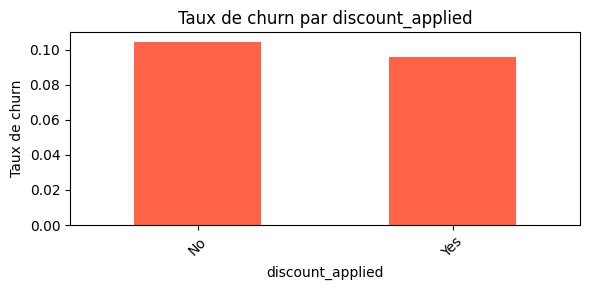

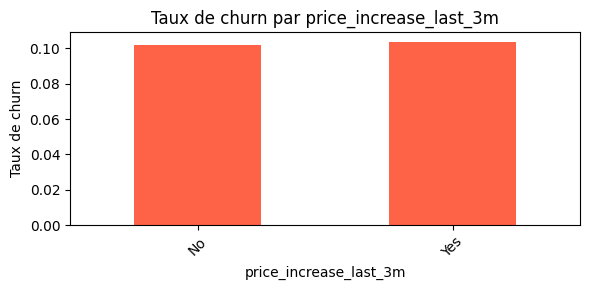

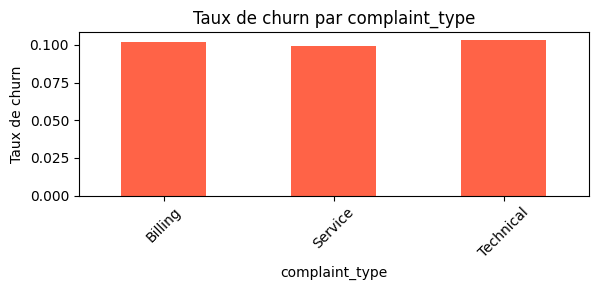

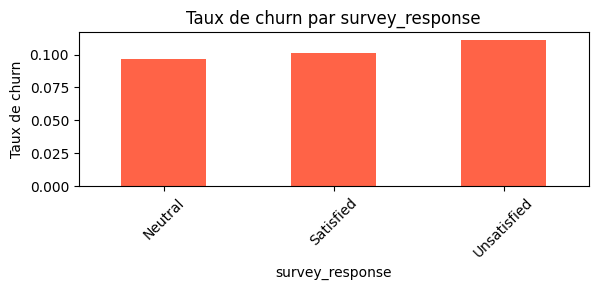

In [10]:
for col in cat_cols:
    if col == 'customer_id':
        continue
    plt.figure(figsize=(6, 3))
    df.groupby(col)['churn'].mean().plot(kind='bar', color='tomato')
    plt.title(f"Taux de churn par {col}")
    plt.ylabel("Taux de churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Figure size 600x300 with 0 Axes>

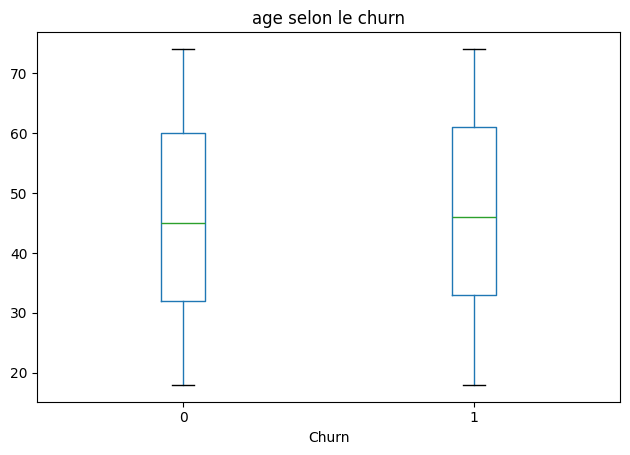

<Figure size 600x300 with 0 Axes>

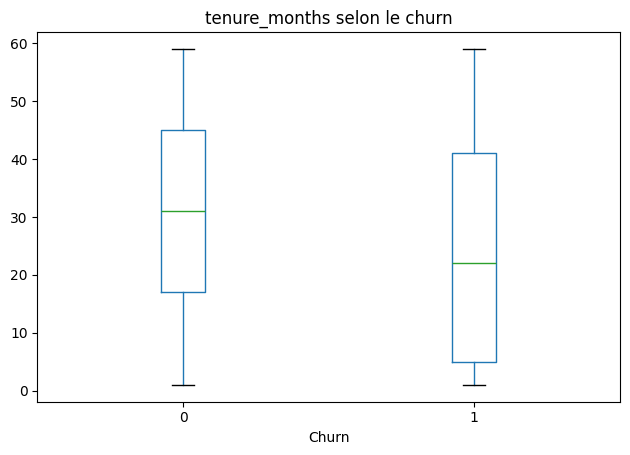

<Figure size 600x300 with 0 Axes>

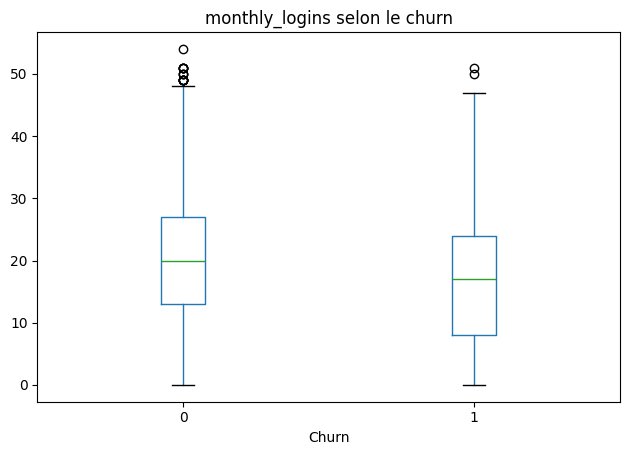

<Figure size 600x300 with 0 Axes>

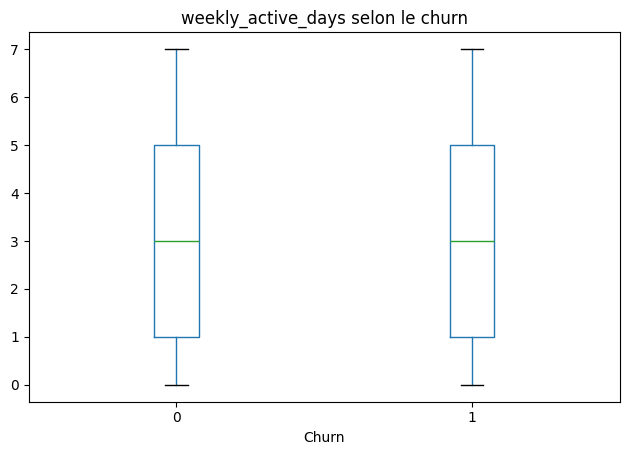

<Figure size 600x300 with 0 Axes>

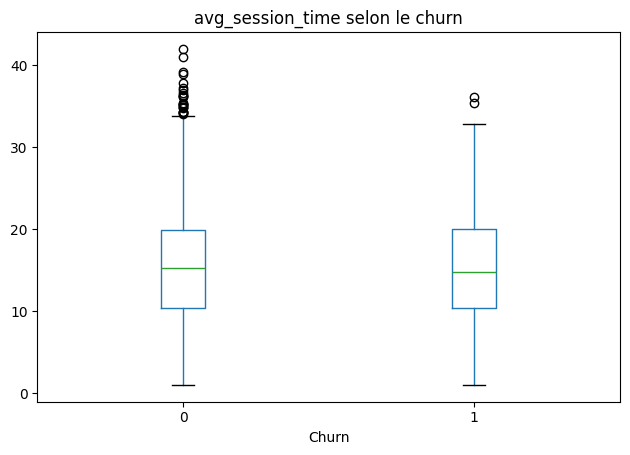

<Figure size 600x300 with 0 Axes>

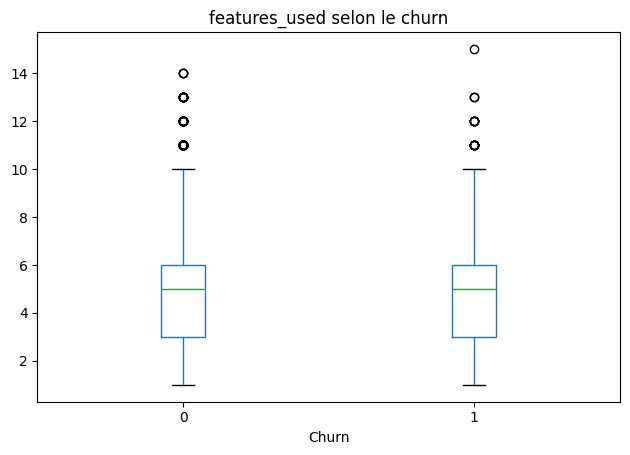

<Figure size 600x300 with 0 Axes>

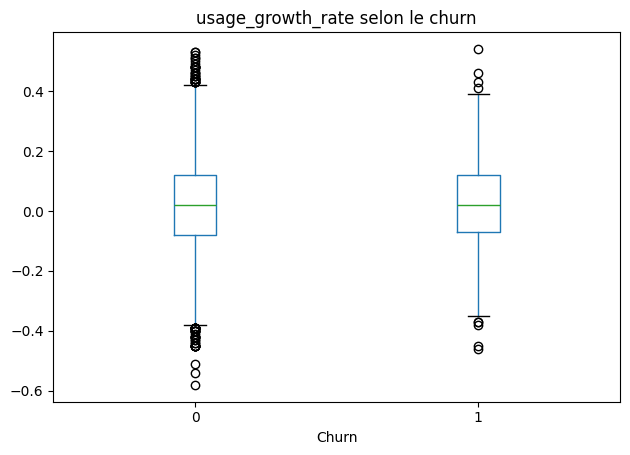

<Figure size 600x300 with 0 Axes>

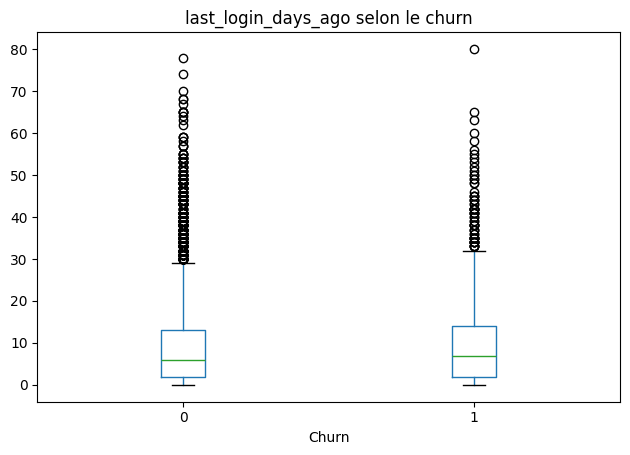

<Figure size 600x300 with 0 Axes>

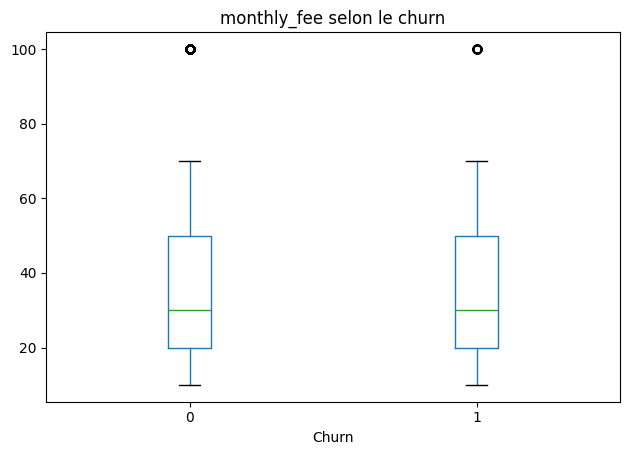

<Figure size 600x300 with 0 Axes>

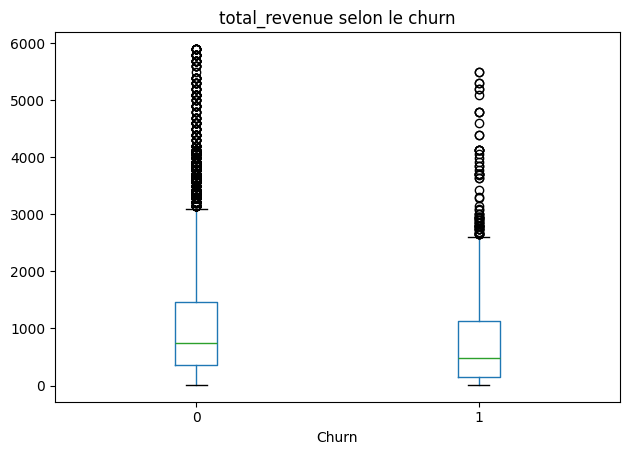

<Figure size 600x300 with 0 Axes>

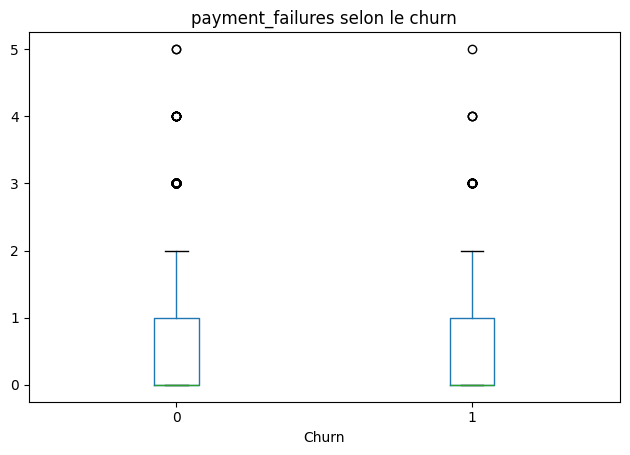

<Figure size 600x300 with 0 Axes>

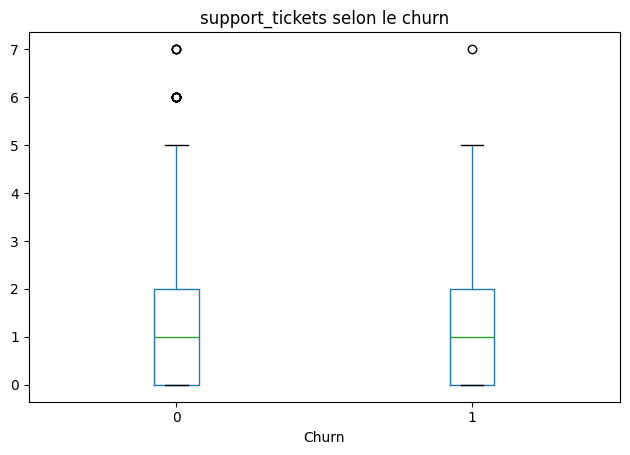

<Figure size 600x300 with 0 Axes>

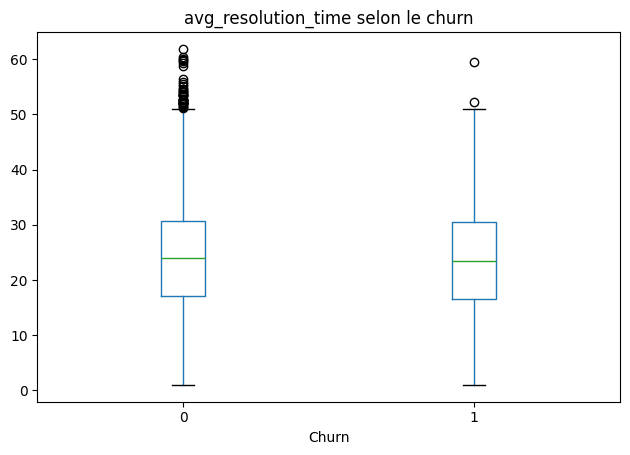

<Figure size 600x300 with 0 Axes>

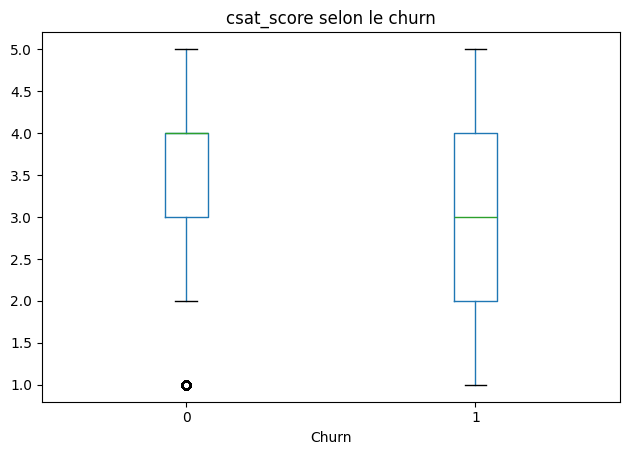

<Figure size 600x300 with 0 Axes>

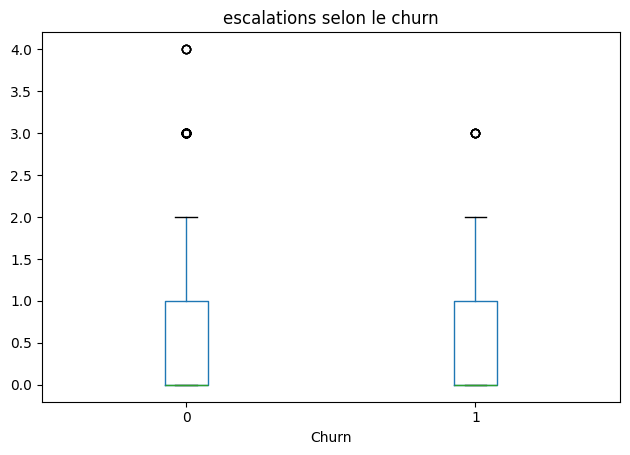

<Figure size 600x300 with 0 Axes>

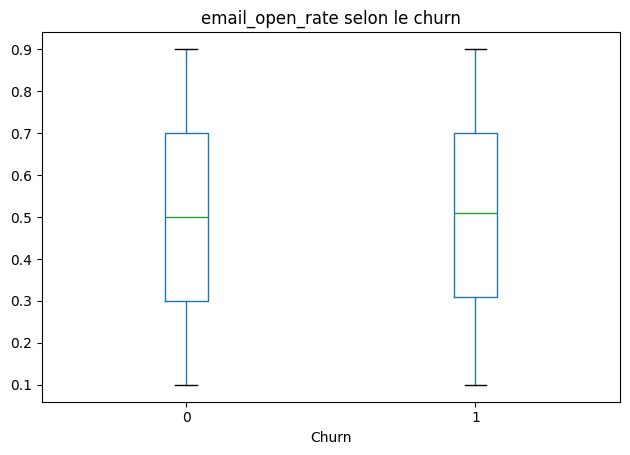

<Figure size 600x300 with 0 Axes>

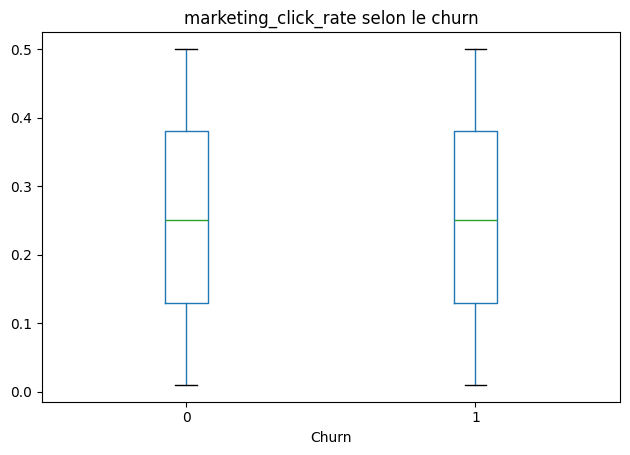

<Figure size 600x300 with 0 Axes>

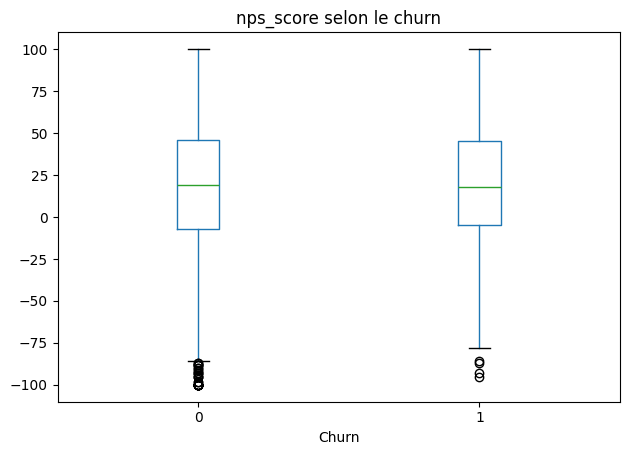

<Figure size 600x300 with 0 Axes>

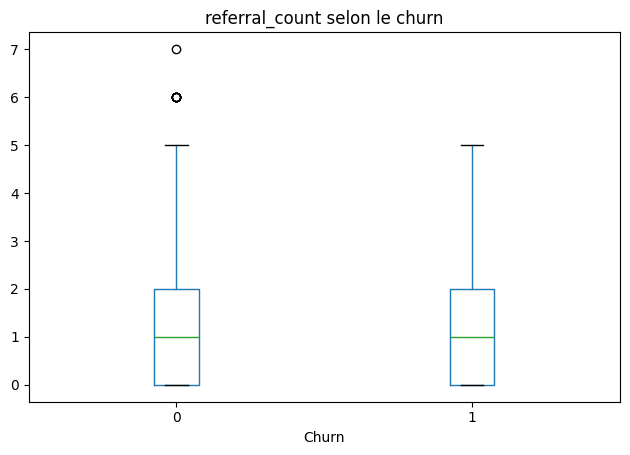

In [11]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    df.boxplot(column=col, by='churn', grid=False)
    plt.title(f"{col} selon le churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.tight_layout()
    plt.show()

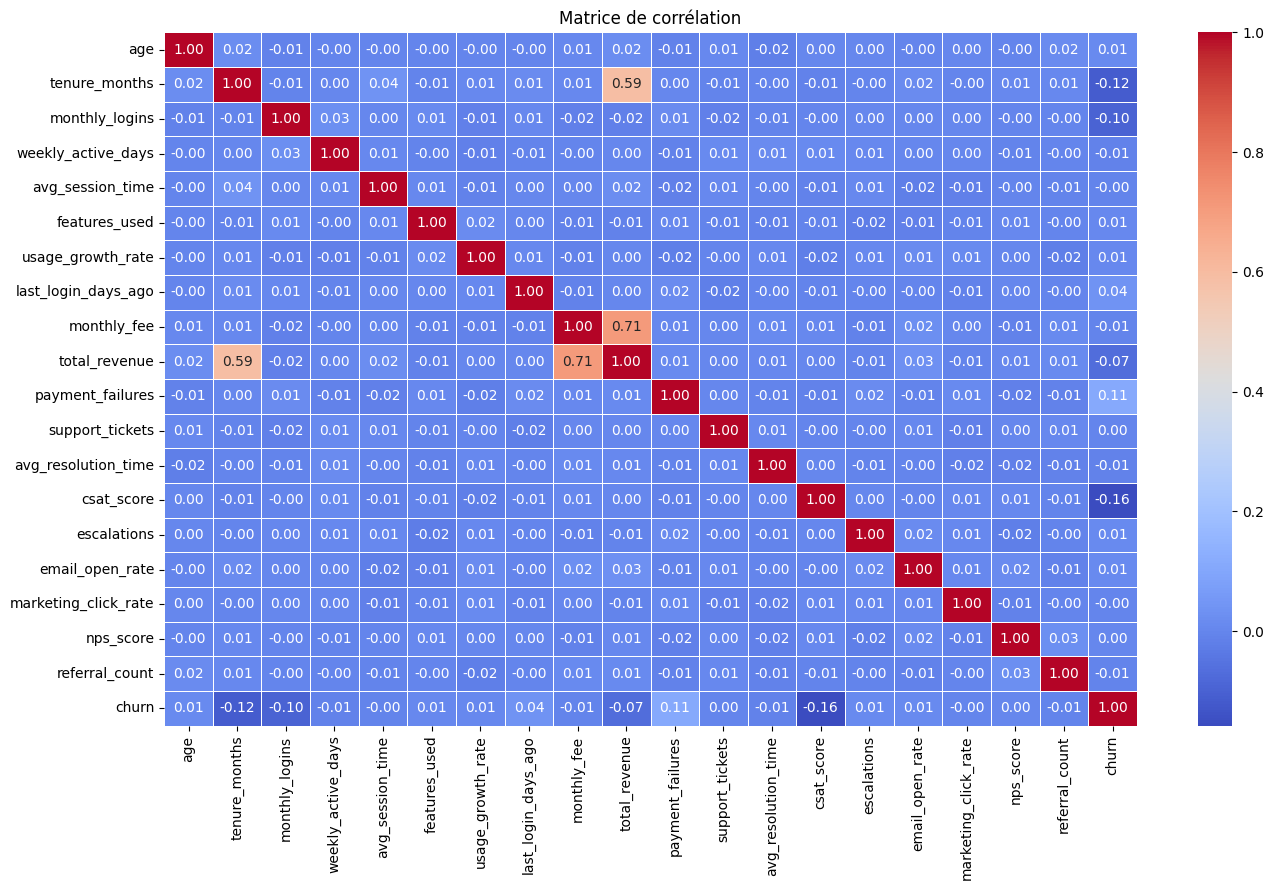

In [12]:
plt.figure(figsize=(14, 9))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.drop(columns=['customer_id'])

cat_cols_to_encode = df_encoded.select_dtypes(include='object').columns
for col in cat_cols_to_encode:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

print(" Encodage terminé")
print(f"Shape final : {df_encoded.shape}")
df_encoded.head()

✅ Encodage terminé
Shape final : (10000, 31)


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,1,68,1,3,2,22,2,0,26,7,...,13.354360,1,4.0,0,0.71,0.40,27,1,1,0
1,0,57,2,5,1,9,0,0,7,5,...,25.140088,0,2.0,0,0.78,0.33,-19,0,2,1
2,1,24,3,4,2,58,2,2,19,5,...,27.572928,1,3.0,0,0.35,0.49,80,0,1,0
3,1,49,0,2,1,19,0,2,34,7,...,26.420822,2,5.0,1,0.83,0.15,100,0,0,0
4,1,65,1,1,1,52,2,0,20,6,...,26.674579,2,4.0,0,0.65,0.44,21,2,1,0


In [14]:
import sys
sys.path.append("..")

from src.train import train_all
models, X_test, y_test = train_all()

✅ logistic entraîné et sauvegardé
✅ random_forest entraîné et sauvegardé
✅ xgboost entraîné et sauvegardé
✅ mlp entraîné et sauvegardé


c:\Users\abdrh\churn-project\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



Modèle : logistic
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.17      0.00      0.01       204

    accuracy                           0.90      2000
   macro avg       0.53      0.50      0.48      2000
weighted avg       0.82      0.90      0.85      2000

ROC-AUC : 0.7251

Modèle : random_forest
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.38      0.01      0.03       204

    accuracy                           0.90      2000
   macro avg       0.64      0.51      0.49      2000
weighted avg       0.85      0.90      0.85      2000

ROC-AUC : 0.7898

Modèle : xgboost
              precision    recall  f1-score   support

           0       0.91      0.99      0.94      1796
           1       0.44      0.09      0.15       204

    accuracy                           0.90      2000
   macro avg       0.67      0.54

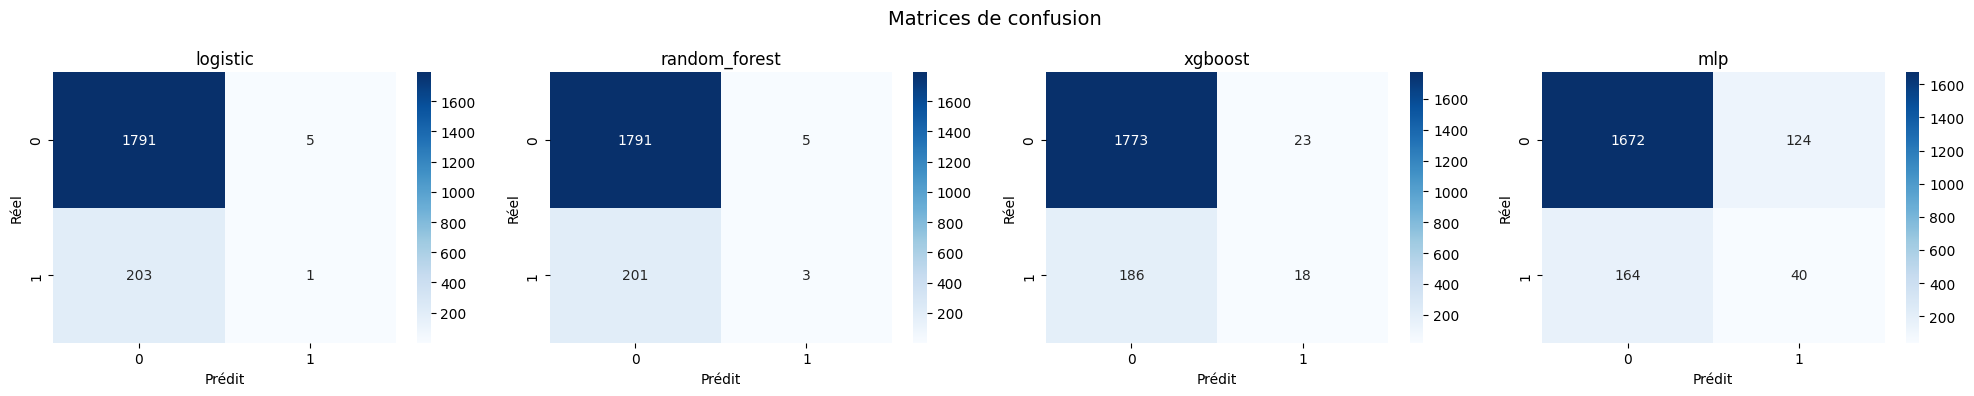

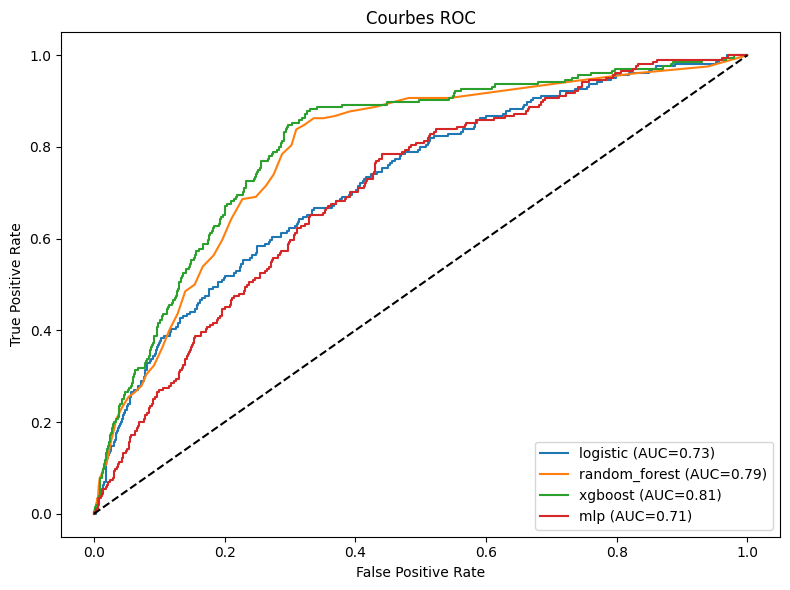

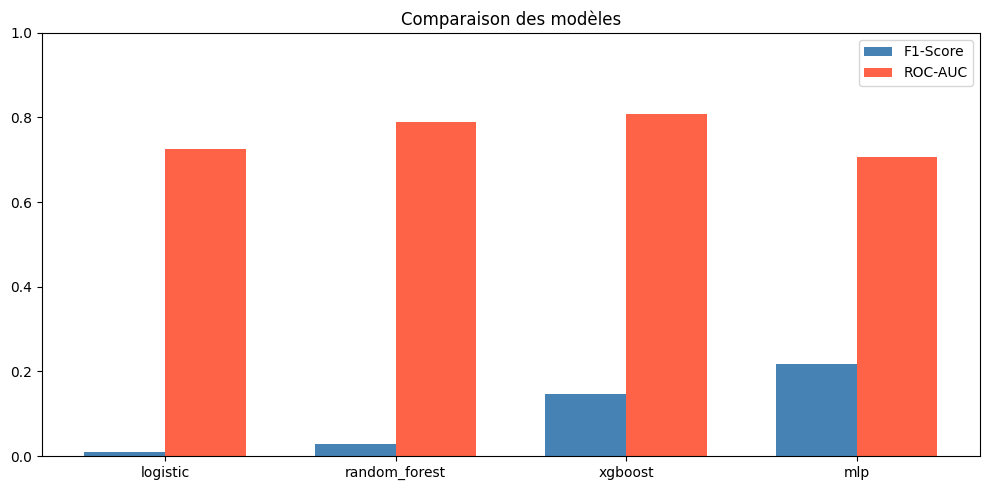

In [15]:
from src.evaluate import evaluate_all, plot_confusion_matrices, plot_roc_curves, plot_comparison

results, y_test = evaluate_all()
plot_confusion_matrices(results, y_test)
plot_roc_curves(results, y_test)
plot_comparison(results)

Type shap_values : <class 'numpy.ndarray'>
Shape : (200, 30, 2)
 SHAP Summary Plot (global)


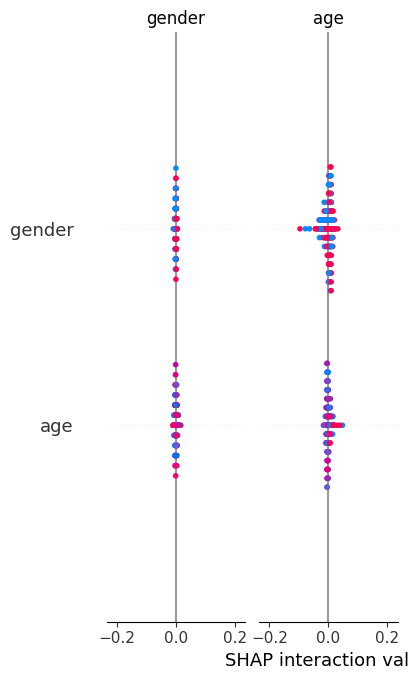

 SHAP Bar Plot


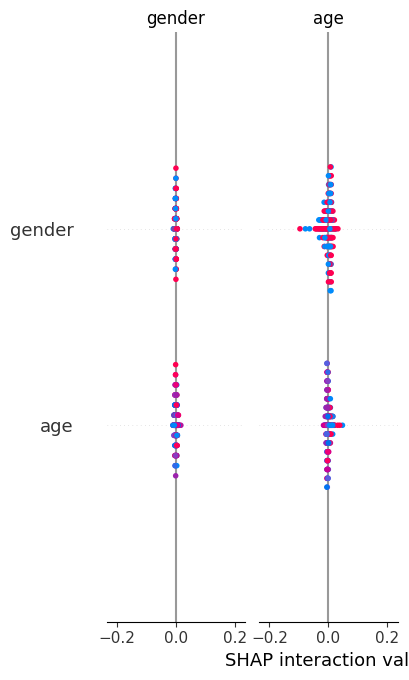

In [17]:
import importlib
import src.shap_analysis
importlib.reload(src.shap_analysis)

from src.shap_analysis import run_shap
run_shap()

In [19]:
import importlib
import src.preprocessing, src.train
importlib.reload(src.preprocessing)
importlib.reload(src.train)

from src.train import train_all
models, X_test, y_test = train_all()

✅ Scaler sauvegardé dans : c:\Users\abdrh\churn-project\models
✅ logistic entraîné et sauvegardé
✅ random_forest entraîné et sauvegardé
✅ xgboost entraîné et sauvegardé
✅ mlp entraîné et sauvegardé


c:\Users\abdrh\churn-project\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [20]:
import pandas as pd
import os

BASE_DIR  = os.path.dirname(os.path.abspath(".."))
df = pd.read_csv("../data/customer_churn.csv")
print(list(df.columns))
print(df.shape)

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']
(10000, 32)
